# ****Import Libraries****

In [1]:
# Standard Imports 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Utilities
sns.set_theme(palette = 'bright')

# ****Import Data****

In [2]:
df = pd.read_csv(r'/kaggle/input/retail-store-sales-dirty-for-data-cleaning/retail_store_sales.csv', parse_dates = ['Transaction Date'])
df.head(10)

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False
5,TXN_7482416,CUST_09,Patisserie,NaN,NaN,10.0,200.0,Credit Card,Online,2023-11-30,NaN
6,TXN_3652209,CUST_07,Food,Item_1_FOOD,5.0,8.0,40.0,Credit Card,In-store,2023-06-10,True
7,TXN_1372952,CUST_21,Furniture,NaN,33.5,NaN,NaN,Digital Wallet,In-store,2024-04-02,True
8,TXN_9728486,CUST_23,Furniture,Item_16_FUR,27.5,1.0,27.5,Credit Card,In-store,2023-04-26,False
9,TXN_2722661,CUST_25,Butchers,Item_22_BUT,36.5,3.0,109.5,Cash,Online,2024-03-14,False


# ****Initial Inspection****

In [3]:
import pandas as pd
from IPython.display import display

def inspection(df):
    print("🚀 DATASET EXPLORATION DASHBOARD")
    print("=" * 40)
    
    # 1. High-Level Summary Table
    summary_data = {
        "Metric": ["Total Rows", "Total Columns", "Duplicate Rows", "Total Missing Cells", "Memory Usage"],
        "Value": [
            f"{df.shape[0]:,}", 
            f"{df.shape[1]:,}", 
            f"{df.duplicated().sum():,}", 
            f"{df.isnull().sum().sum():,}",
            f"{df.memory_usage(deep=True).sum() / 1024**2:.2f} MB"
        ]
    }
    display(pd.DataFrame(summary_data).style.hide(axis='index').set_properties(**{'text-align': 'left', 'font-weight': 'bold'}))

    # 2. Enhanced Colored Info Table
    print('\n📋 COLUMN METADATA & MEMORY')
    
    # Building the info dataframe manually
    info_df = pd.DataFrame({
        "Column": df.columns,
        "Type": df.dtypes.values,
        "Non-Null Count": df.notnull().sum().values,
        "Null Count": df.isnull().sum().values,
        "Null %": (df.isnull().sum().values / len(df) * 100).round(2),
        "Unique Values": df.nunique().values
    })

    # Styling the table
    styled_info = info_df.style.background_gradient(subset=['Null %'], cmap='Reds') \
        .background_gradient(subset=['Unique Values'], cmap='Blues') \
        .format({"Null %": "{:.1f}%"}) \
        .set_table_styles([
            {'selector': 'th', 'props': [('background-color', '#4b4b4b'), ('color', 'white'), ('text-align', 'center')]},
            {'selector': 'td', 'props': [('text-align', 'center')]}
        ])

    display(styled_info)

# Execute
inspection(df)


🚀 DATASET EXPLORATION DASHBOARD


Metric,Value
Total Rows,"12,575"
Total Columns,11
Duplicate Rows,0
Total Missing Cells,"7,229"
Memory Usage,5.01 MB



📋 COLUMN METADATA & MEMORY


,Column,Type,Non-Null Count,Null Count,Null %,Unique Values
0,Transaction ID,object,12575,0,0.0%,12575
1,Customer ID,object,12575,0,0.0%,25
2,Category,object,12575,0,0.0%,8
3,Item,object,11362,1213,9.7%,200
4,Price Per Unit,float64,11966,609,4.8%,25
5,Quantity,float64,11971,604,4.8%,10
6,Total Spent,float64,11971,604,4.8%,227
7,Payment Method,object,12575,0,0.0%,3
8,Location,object,12575,0,0.0%,2
9,Transaction Date,datetime64[ns],12575,0,0.0%,1114


# ****Exploratory Data Analysis****

### ****Single Variate Analysis****

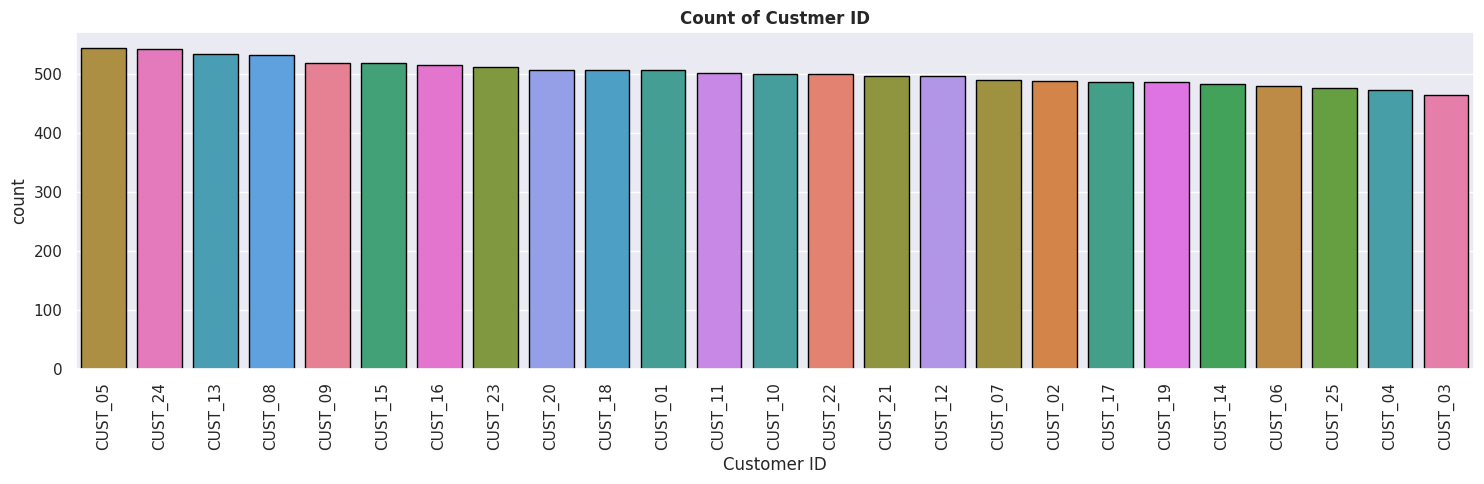

In [4]:
plt.figure(figsize = (15, 5))
sns.countplot(data = df, x = 'Customer ID', hue = 'Customer ID', order = df['Customer ID'].value_counts().index, edgecolor = 'black')
plt.title('Count of Custmer ID', fontweight = 'bold')
plt.xticks(rotation = 90)
plt.tight_layout()
plt.show()

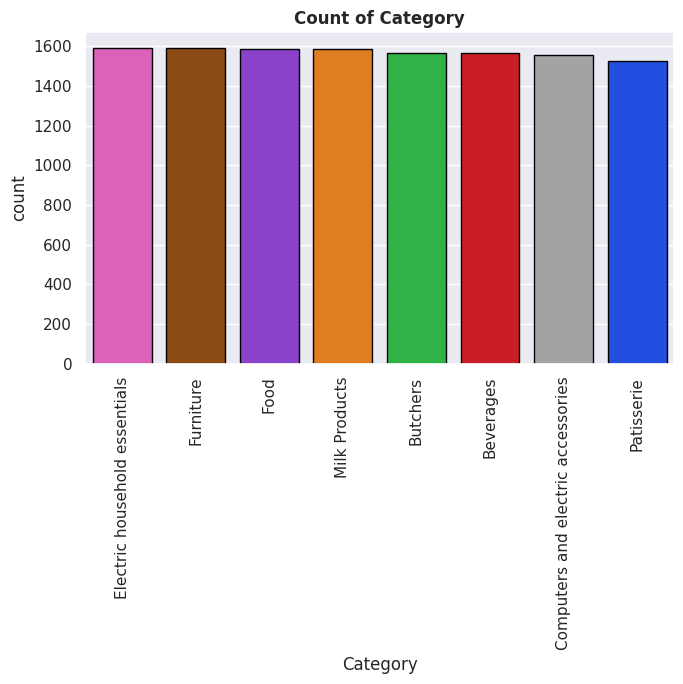

In [5]:
plt.figure(figsize = (7, 7))
sns.countplot(data = df, x = 'Category', hue = 'Category', order = df['Category'].value_counts().index, edgecolor = 'black')
plt.title('Count of Category', fontweight = 'bold')
plt.xticks(rotation = 90)
plt.tight_layout()
plt.show()

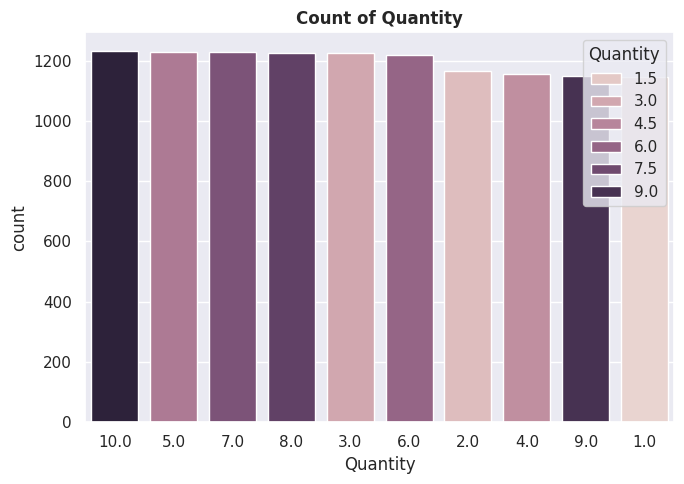

In [6]:
plt.figure(figsize = (7, 5))
sns.countplot(data = df, x = 'Quantity', hue = 'Quantity', order = df['Quantity'].value_counts().index)
plt.title('Count of Quantity', fontweight = 'bold')
plt.tight_layout()
plt.show()

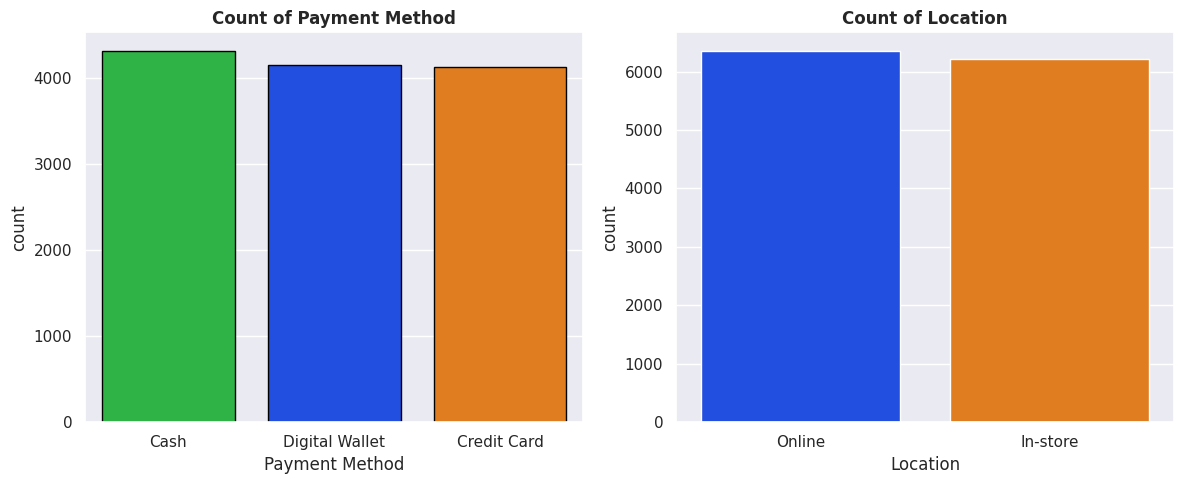

In [7]:
fig, axis = plt.subplots(1, 2, figsize = (12, 5))
sns.countplot(data = df, x = 'Payment Method', hue = 'Payment Method', order = df['Payment Method'].value_counts().index, edgecolor = 'black', ax = axis[0])
axis[0].set_title('Count of Payment Method', fontweight = 'bold')

sns.countplot(data = df, x = 'Location', hue = 'Location', order = df['Location'].value_counts().index, ax = axis[1])
axis[1].set_title('Count of Location', fontweight = 'bold')

plt.tight_layout()
plt.show()

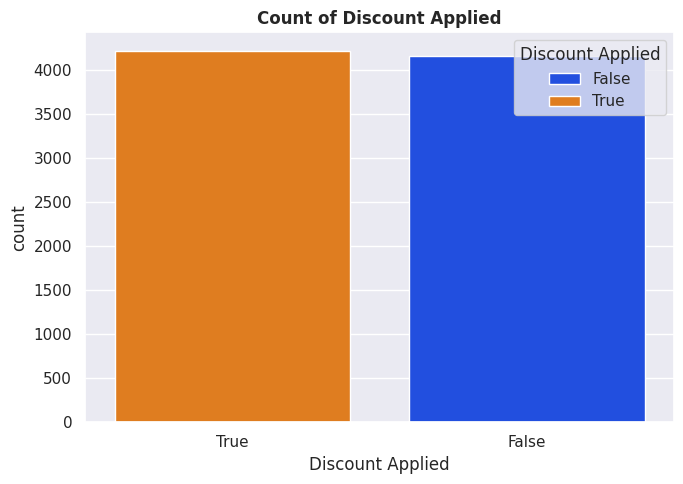

In [8]:
plt.figure(figsize = (7, 5))
sns.countplot(data = df, x = 'Discount Applied', hue = 'Discount Applied', order = df['Discount Applied'].value_counts().index)
plt.title('Count of Discount Applied', fontweight = 'bold')
plt.tight_layout()
plt.show()

### ****Mutivariate Analysis****

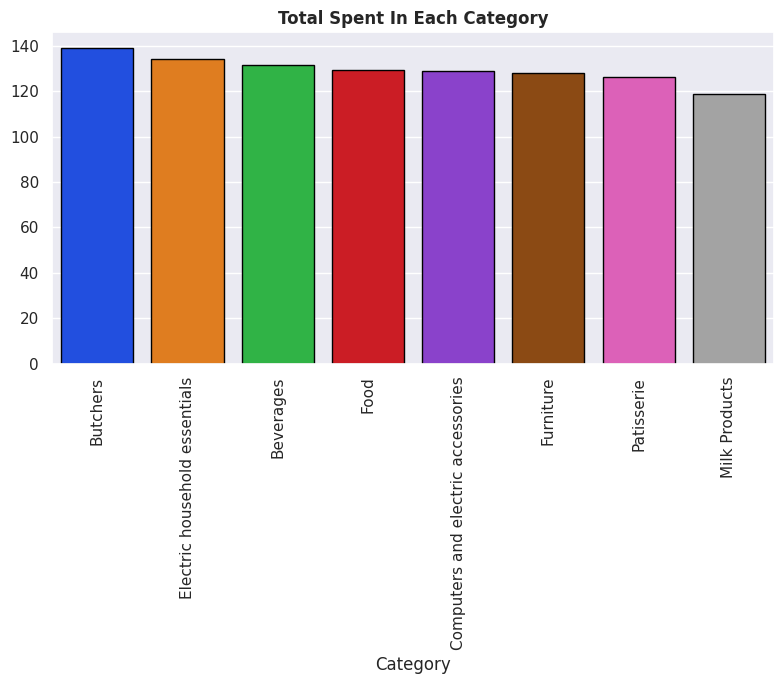

In [9]:
group1 = df.groupby('Category')['Total Spent'].mean().sort_values(ascending = False)

plt.figure(figsize = (8, 7))
sns.barplot(x = group1.index, y = group1.values, hue = group1.index, edgecolor = 'black')
plt.title('Total Spent In Each Category', fontweight = 'bold')
plt.xticks(rotation = 90)
plt.tight_layout()
plt.show()

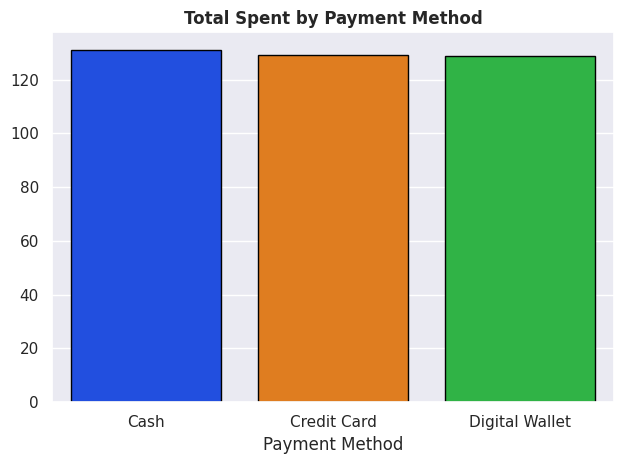

In [10]:
group2 = df.groupby('Payment Method')['Total Spent'].mean().sort_values(ascending = False)

sns.barplot(x = group2.index, y = group2.values, hue = group2.index, edgecolor = 'black')
plt.title('Total Spent by Payment Method', fontweight = 'bold')
plt.tight_layout()
plt.show()

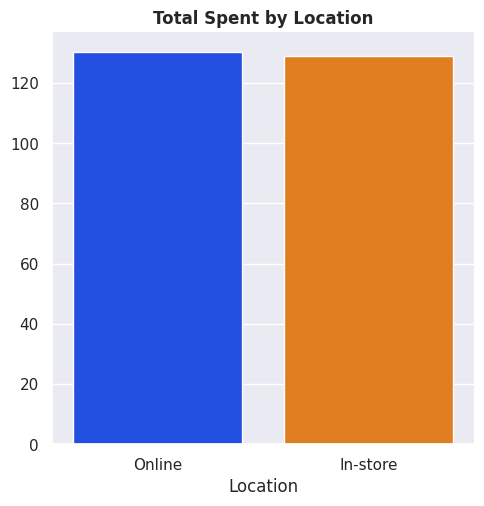

In [11]:
group3 = df.groupby('Location')['Total Spent'].mean().sort_values(ascending = False)

sns.catplot(x = group3.index, y = group3.values, hue = group3.index, kind = 'bar')
plt.title('Total Spent by Location', fontweight = 'bold')
plt.show()

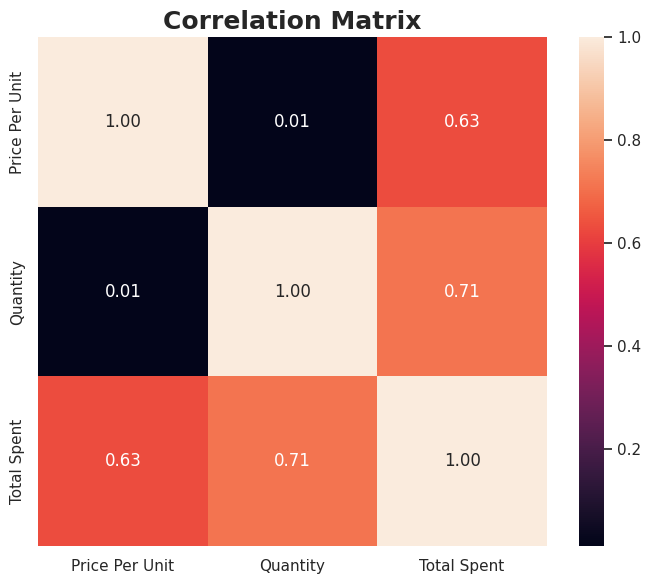

In [12]:
plt.figure(figsize = (7, 6))
sns.heatmap(df.corr(numeric_only = True), annot = True, fmt = '.2f')
plt.title('Correlation Matrix', fontweight = 'bold', fontsize = 18)
plt.tight_layout()
plt.show()

# ****Check For missig Data****

In [13]:
df[(df['Total Spent'].isnull()) & (df['Quantity'].isnull())]

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
7,TXN_1372952,CUST_21,Furniture,NaN,33.5,NaN,NaN,Digital Wallet,In-store,2024-04-02,True
15,TXN_1809665,CUST_14,Beverages,NaN,24.5,NaN,NaN,Credit Card,In-store,2022-05-11,NaN
19,TXN_4206593,CUST_01,Furniture,NaN,35.0,NaN,NaN,Digital Wallet,Online,2025-01-13,False
25,TXN_3481599,CUST_05,Furniture,NaN,39.5,NaN,NaN,Cash,Online,2022-09-08,False
34,TXN_1621497,CUST_06,Patisserie,NaN,23.0,NaN,NaN,Cash,In-store,2023-02-18,NaN
...,...,...,...,...,...,...,...,...,...,...,...
12527,TXN_1069238,CUST_23,Food,NaN,5.0,NaN,NaN,Digital Wallet,In-store,2022-08-13,False
12552,TXN_4823896,CUST_05,Milk Products,NaN,8.0,NaN,NaN,Cash,In-store,2022-07-21,False
12556,TXN_4397672,CUST_04,Beverages,NaN,41.0,NaN,NaN,Credit Card,Online,2024-11-28,True
12562,TXN_7422454,CUST_07,Butchers,NaN,33.5,NaN,NaN,Cash,Online,2023-04-15,NaN


In [14]:
df[df['Price Per Unit'].isna()]

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
5,TXN_7482416,CUST_09,Patisserie,NaN,NaN,10.0,200.0,Credit Card,Online,2023-11-30,NaN
11,TXN_5422631,CUST_09,Milk Products,NaN,NaN,8.0,52.0,Digital Wallet,In-store,2025-01-12,True
17,TXN_9634894,CUST_15,Milk Products,NaN,NaN,10.0,275.0,Digital Wallet,Online,2022-04-17,NaN
21,TXN_8685338,CUST_15,Milk Products,NaN,NaN,3.0,105.0,Credit Card,In-store,2023-10-29,NaN
32,TXN_1543244,CUST_20,Food,NaN,NaN,8.0,196.0,Credit Card,Online,2024-10-25,True
...,...,...,...,...,...,...,...,...,...,...,...
12435,TXN_5147764,CUST_01,Furniture,NaN,NaN,5.0,32.5,Credit Card,Online,2023-09-06,True
12457,TXN_1352194,CUST_17,Electric household essentials,NaN,NaN,4.0,86.0,Credit Card,Online,2023-02-26,NaN
12477,TXN_5625684,CUST_22,Computers and electric accessories,NaN,NaN,4.0,80.0,Cash,In-store,2022-11-09,True
12491,TXN_7894525,CUST_23,Butchers,NaN,NaN,1.0,26.0,Credit Card,Online,2023-01-31,True


In [15]:
df[(df['Item'].isna()) & (df['Price Per Unit'].isna())]

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
5,TXN_7482416,CUST_09,Patisserie,NaN,NaN,10.0,200.0,Credit Card,Online,2023-11-30,NaN
11,TXN_5422631,CUST_09,Milk Products,NaN,NaN,8.0,52.0,Digital Wallet,In-store,2025-01-12,True
17,TXN_9634894,CUST_15,Milk Products,NaN,NaN,10.0,275.0,Digital Wallet,Online,2022-04-17,NaN
21,TXN_8685338,CUST_15,Milk Products,NaN,NaN,3.0,105.0,Credit Card,In-store,2023-10-29,NaN
32,TXN_1543244,CUST_20,Food,NaN,NaN,8.0,196.0,Credit Card,Online,2024-10-25,True
...,...,...,...,...,...,...,...,...,...,...,...
12435,TXN_5147764,CUST_01,Furniture,NaN,NaN,5.0,32.5,Credit Card,Online,2023-09-06,True
12457,TXN_1352194,CUST_17,Electric household essentials,NaN,NaN,4.0,86.0,Credit Card,Online,2023-02-26,NaN
12477,TXN_5625684,CUST_22,Computers and electric accessories,NaN,NaN,4.0,80.0,Cash,In-store,2022-11-09,True
12491,TXN_7894525,CUST_23,Butchers,NaN,NaN,1.0,26.0,Credit Card,Online,2023-01-31,True


# ****`DESCRIPTION OF DATA : `****

| 🏷️ **Column Name**      | 📝 **Description**                                                                               | 🔍 **Example Values**   |
| ------------------------ | ------------------------------------------------------------------------------------------------ | ----------------------- |
| 🆔 **Transaction ID**    | Unique identifier for each transaction. Always present and guaranteed to be unique.              | `TXN_1234567`           |
| 👤 **Customer ID**       | Unique identifier for each customer. Contains 25 distinct customers in the dataset.              | `CUST_01`               |
| 🗂️ **Category**         | Product category of the purchased item.                                                          | `Food`, `Furniture`     |
| 🛒 **Item**              | Name of the purchased item. May contain missing or `None` values.                                | `Item_1_FOOD`, `None`   |
| 💲 **Price Per Unit**    | Static price of a single unit. May contain missing or `None` values.                             | `4.00`, `None`          |
| 🔢 **Quantity**          | Number of units purchased. May include missing or `None` values.                                 | `1`, `None`             |
| 💰 **Total Spent**       | Total transaction value calculated as **Quantity × Price Per Unit**. May contain missing values. | `8.00`, `None`          |
| 💳 **Payment Method**    | Mode of payment used in the transaction. May contain missing or invalid values.                  | `Cash`, `Credit Card`   |
| 📍 **Location**          | Transaction channel or place of purchase. May contain missing or invalid values.                 | `In-store`, `Online`    |
| 📅 **Transaction Date**  | Date when the transaction occurred. Always present and valid.                                    | `2023-01-15`            |
| 🎟️ **Discount Applied** | Indicates whether a discount was applied to the transaction. May contain missing values.         | `True`, `False`, `None` |


## 🛍️ Product Catalog

### ⚡ Electric Household Essentials

| 🆔 Item Code | 🔌 Item | 💲 Price |
|--------------|--------|----------|
| Item_1_EHE | 🔌 Blender | 5.0 |
| Item_2_EHE | 🍲 Microwave | 6.5 |
| Item_3_EHE | 🍞 Toaster | 8.0 |
| Item_4_EHE | 🧹 Vacuum Cleaner | 9.5 |
| Item_5_EHE | 🌬️ Air Purifier | 11.0 |
| Item_6_EHE | ☕ Electric Kettle | 12.5 |
| Item_7_EHE | 🍚 Rice Cooker | 14.0 |
| Item_8_EHE | 👕 Iron | 15.5 |
| Item_9_EHE | 🌀 Ceiling Fan | 17.0 |
| Item_10_EHE | 🌪️ Table Fan | 18.5 |
| Item_11_EHE | 💨 Hair Dryer | 20.0 |
| Item_12_EHE | 🔥 Heater | 21.5 |
| Item_13_EHE | 💧 Humidifier | 23.0 |
| Item_14_EHE | 🌫️ Dehumidifier | 24.5 |
| Item_15_EHE | ☕ Coffee Maker | 26.0 |
| Item_16_EHE | ❄️ Portable AC | 27.5 |
| Item_17_EHE | 🍳 Electric Stove | 29.0 |
| Item_18_EHE | 🍲 Pressure Cooker | 30.5 |
| Item_19_EHE | 🍳 Induction Cooktop | 32.0 |
| Item_20_EHE | 🚰 Water Dispenser | 33.5 |
| Item_21_EHE | 🥤 Hand Blender | 35.0 |
| Item_22_EHE | ⚙️ Mixer Grinder | 36.5 |
| Item_23_EHE | 🥪 Sandwich Maker | 38.0 |
| Item_24_EHE | 🍟 Air Fryer | 39.5 |
| Item_25_EHE | 🧃 Juicer | 41.0 |

### 🪑 Furniture Collection

| 🆔 Item Code | 🛋️ Item | 💲 Price |
|--------------|--------|----------|
| Item_1_FUR | 🪑 Office Chair | 5.0 |
| Item_2_FUR | 🛋️ Sofa | 6.5 |
| Item_3_FUR | ☕ Coffee Table | 8.0 |
| Item_4_FUR | 🍽️ Dining Table | 9.5 |
| Item_5_FUR | 📚 Bookshelf | 11.0 |
| Item_6_FUR | 🛏️ Bed Frame | 12.5 |
| Item_7_FUR | 🚪 Wardrobe | 14.0 |
| Item_8_FUR | 📖 Study Table | 15.5 |
| Item_9_FUR | 🛋️ Recliner | 17.0 |
| Item_10_FUR | 🪑 Side Table | 18.5 |
| Item_11_FUR | 📺 TV Stand | 20.0 |
| Item_12_FUR | 🪞 Dressing Table | 21.5 |
| Item_13_FUR | 🗄️ Chest of Drawers | 23.0 |
| Item_14_FUR | 🧸 Ottoman | 24.5 |
| Item_15_FUR | 🎠 Rocking Chair | 26.0 |
| Item_16_FUR | 👟 Shoe Rack | 27.5 |
| Item_17_FUR | 🌙 Nightstand | 29.0 |
| Item_18_FUR | 🌳 Patio Chair | 30.5 |
| Item_19_FUR | 📐 Folding Table | 32.0 |
| Item_20_FUR | 🛋️ Bean Bag | 33.5 |
| Item_21_FUR | 🪵 Wooden Bench | 35.0 |
| Item_22_FUR | 📦 Corner Shelf | 36.5 |
| Item_23_FUR | 📰 Magazine Rack | 38.0 |
| Item_24_FUR | 🍸 Bar Stool | 39.5 |
| Item_25_FUR | 🪑 Accent Chair | 41.0 |

# 🔎 Observations & Data Cleaning Strategy

After performing a detailed data audit, the following key insights were identified:

---

## 📌 1️⃣ Missing Data Pattern

⚠️ Significant missing values were found in the following columns:

- 🛒 `Item`
- 💲 `Price Per Unit`
- 🔢 `Quantity`
- 💰 `Total Spent`

These missing values appear **randomly distributed**, indicating non-systematic data entry gaps rather than structural absence.

---

## 🔗 2️⃣ Strong Column Correlation

The following transactional columns are mathematically dependent:

- 💲 `Price Per Unit`
- 🔢 `Quantity`
- 💰 `Total Spent`

Since:

$$
\textbf{Total Spent} = \textbf{Price Per Unit} \times \textbf{Quantity}
$$

This dependency enables logical reconstruction of missing values.

---

## 🧮 3️⃣ Formula-Based Imputation Strategy

Wherever one of the transactional variables is missing:

- If `Total Spent` is missing → compute using multiplication  
- If `Price Per Unit` is missing → derive using division  
- If `Quantity` is missing → derive using division  

This ensures **logical consistency instead of random imputation**.

---

## 🗂️ 4️⃣ Product Catalog-Based Recovery

The `Product Catalog` can be used to:

- Restore missing 🛒 `Item` values
- Validate 💲 `Price Per Unit`
- Cross-check pricing consistency

This guarantees alignment with the master product list.

---

## 🎟️ 5️⃣ Handling `Discount Applied`

Options available:

- 🗑️ Drop the column if it adds no predictive value  
- 🎲 Replace null values strategically (e.g., rule-based or probabilistic assignment)

Decision should depend on downstream modeling objectives.

---

## ✅ Strategic Outcome

By leveraging:
- Mathematical relationships  
- Master product catalog  
- Logical validation rules  

We transform noisy transactional data into a **structured, reliable, and analytics-ready dataset**.

---

# ****Data Cleaning****

#### ***1. Calculate null in `Quantity` by random Sampling  and then calculate `Price Per Unit` column using `Total Spent` and `Quantity`.***

In [16]:
df['Quantity'][df['Quantity'].isnull()] = df['Quantity'].dropna().sample(df['Quantity'].isna().sum()).values

df['New Price Per Unit'] = df['Total Spent'] / df['Quantity']

df['Price Per Unit'] = df['Price Per Unit'].fillna(df['New Price Per Unit'])

df['Total Spent'] = df['Price Per Unit'] * df['Quantity']

df.drop(columns = 'New Price Per Unit', inplace = True)

/tmp/ipykernel_17/3803019265.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['Quantity'][df['Quantity'].isnull()] = df['Quantity'].dropna().sample(df['Quantity'].isna().sum()).values
/tmp/ipykernel_17/3803019265.py:1: SettingWithCopyW

#### ***2. Drop Remaining Rows Which has Both `Quantity` and `Total Spent` is null.***
***Due to this we have to undergo loss of 604 rows.***

In [17]:
df = df.dropna(subset = ['Quantity', 'Total Spent'])

#### ***3. Calculate Null in `Items`.***
- to Calculate null frst we have to make a reference table. to assign Item code based on `Category` and `Price Per Unit` columns.
- This is reference-based conditional mapping problem.
- First we construct new master reference data. which contains columns `category`, `Item`, `Price Per Unit` and `Item name`.
- then merged our ***`df`*** and ***`master data df`*** on `category` and `Item`. and then dropped `Item` column having null values.

In [18]:
category_codes = {
        "Electric household essentials": "EHE",
        "Furniture": "FUR",
        "Patisserie": "PAT",
        "Milk Products": "MILK",
        "Butchers": "BUT",
        "Beverages": "BEV",
        "Food": "FOOD",
        "Computers and electric accessories": "CEA"
    }

In [19]:
allItems = {
    "Item_1_FUR": "Office Chair",
    "Item_2_FUR": "Sofa",
    "Item_3_FUR": "Coffee Table",
    "Item_4_FUR": "Dining Table",
    "Item_5_FUR": "Bookshelf",
    "Item_6_FUR": "Bed Frame",
    "Item_7_FUR": "Wardrobe",
    "Item_8_FUR": "Study Table",
    "Item_9_FUR": "Recliner",
    "Item_10_FUR": "Side Table",
    "Item_11_FUR": "TV Stand",
    "Item_12_FUR": "Dressing Table",
    "Item_13_FUR": "Chest of Drawers",
    "Item_14_FUR": "Ottoman",
    "Item_15_FUR": "Rocking Chair",
    "Item_16_FUR": "Shoe Rack",
    "Item_17_FUR": "Nightstand",
    "Item_18_FUR": "Patio Chair",
    "Item_19_FUR": "Folding Table",
    "Item_20_FUR": "Bean Bag",
    "Item_21_FUR": "Wooden Bench",
    "Item_22_FUR": "Corner Shelf",
    "Item_23_FUR": "Magazine Rack",
    "Item_24_FUR": "Bar Stool",
    "Item_25_FUR": "Accent Chair",
    "Item_1_EHE": "Blender",
    "Item_2_EHE": "Microwave",
    "Item_3_EHE": "Toaster",
    "Item_4_EHE": "Vacuum Cleaner",
    "Item_5_EHE": "Air Purifier",
    "Item_6_EHE": "Electric Kettle",
    "Item_7_EHE": "Rice Cooker",
    "Item_8_EHE": "Iron",
    "Item_9_EHE": "Ceiling Fan",
    "Item_10_EHE": "Table Fan",
    "Item_11_EHE": "Hair Dryer",
    "Item_12_EHE": "Heater",
    "Item_13_EHE": "Humidifier",
    "Item_14_EHE": "Dehumidifier",
    "Item_15_EHE": "Coffee Maker",
    "Item_16_EHE": "Portable AC",
    "Item_17_EHE": "Electric Stove",
    "Item_18_EHE": "Pressure Cooker",
    "Item_19_EHE": "Induction Cooktop",
    "Item_20_EHE": "Water Dispenser",
    "Item_21_EHE": "Hand Blender",
    "Item_22_EHE": "Mixer Grinder",
    "Item_23_EHE": "Sandwich Maker",
    "Item_24_EHE": "Air Fryer",
    "Item_25_EHE": "Juicer",
    "Item_1_BUT": "Chicken Breast",
    "Item_2_BUT": "Chicken Thigh",
    "Item_3_BUT": "Whole Chicken",
    "Item_4_BUT": "Beef Mince",
    "Item_5_BUT": "Beef Steak",
    "Item_6_BUT": "Lamb Chops",
    "Item_7_BUT": "Mutton Curry Cut",
    "Item_8_BUT": "Turkey Breast",
    "Item_9_BUT": "Pork Chops",
    "Item_10_BUT": "Bacon Pack",
    "Item_11_BUT": "Sausages",
    "Item_12_BUT": "Meatballs",
    "Item_13_BUT": "Beef Ribs",
    "Item_14_BUT": "Lamb Leg",
    "Item_15_BUT": "Chicken Wings",
    "Item_16_BUT": "Ham Slices",
    "Item_17_BUT": "Smoked Turkey",
    "Item_18_BUT": "Goat Meat",
    "Item_19_BUT": "Pork Belly",
    "Item_20_BUT": "Ribeye Steak",
    "Item_21_BUT": "Marinated Chicken",
    "Item_22_BUT": "Minced Pork",
    "Item_23_BUT": "Lamb Shank",
    "Item_24_BUT": "Beef Tenderloin",
    "Item_25_BUT": "Premium Wagyu Cut",
    "Item_1_PAT": "Croissant",
    "Item_2_PAT": "Chocolate Croissant",
    "Item_3_PAT": "Muffin",
    "Item_4_PAT": "Cupcake",
    "Item_5_PAT": "Danish Pastry",
    "Item_6_PAT": "Donut",
    "Item_7_PAT": "Eclair",
    "Item_8_PAT": "Brownie",
    "Item_9_PAT": "Macaron",
    "Item_10_PAT": "Cinnamon Roll",
    "Item_11_PAT": "Cheesecake Slice",
    "Item_12_PAT": "Fruit Tart",
    "Item_13_PAT": "Cream Puff",
    "Item_14_PAT": "Lemon Tart",
    "Item_15_PAT": "Apple Pie Slice",
    "Item_16_PAT": "Chocolate Tart",
    "Item_17_PAT": "Choux Pastry",
    "Item_18_PAT": "Tiramisu Slice",
    "Item_19_PAT": "Red Velvet Slice",
    "Item_20_PAT": "Carrot Cake Slice",
    "Item_21_PAT": "Cookie Pack",
    "Item_22_PAT": "Cake Roll",
    "Item_23_PAT": "Mini Pastry Box",
    "Item_24_PAT": "Premium Donut",
    "Item_25_PAT": "French Pastry Box",
    "Item_1_BEV": "Mineral Water",
    "Item_2_BEV": "Sparkling Water",
    "Item_3_BEV": "Cola Drink",
    "Item_4_BEV": "Orange Juice",
    "Item_5_BEV": "Apple Juice",
    "Item_6_BEV": "Lemonade",
    "Item_7_BEV": "Energy Drink",
    "Item_8_BEV": "Iced Tea",
    "Item_9_BEV": "Cold Coffee",
    "Item_10_BEV": "Sports Drink",
    "Item_11_BEV": "Ginger Ale",
    "Item_12_BEV": "Tonic Water",
    "Item_13_BEV": "Grape Juice",
    "Item_14_BEV": "Coconut Water",
    "Item_15_BEV": "Mango Juice",
    "Item_16_BEV": "Herbal Tea",
    "Item_17_BEV": "Green Tea Bottle",
    "Item_18_BEV": "Kombucha",
    "Item_19_BEV": "Pineapple Juice",
    "Item_20_BEV": "Fruit Punch",
    "Item_21_BEV": "Protein Shake",
    "Item_22_BEV": "Milkshake",
    "Item_23_BEV": "Smoothie",
    "Item_24_BEV": "Iced Latte",
    "Item_25_BEV": "Premium Cold Brew",
    "Item_1_MILK": "Full Cream Milk",
    "Item_2_MILK": "Skimmed Milk",
    "Item_3_MILK": "Cheese Block",
    "Item_4_MILK": "Butter",
    "Item_5_MILK": "Yogurt",
    "Item_6_MILK": "Greek Yogurt",
    "Item_7_MILK": "Fresh Cream",
    "Item_8_MILK": "Cottage Cheese",
    "Item_9_MILK": "Chocolate Milk",
    "Item_10_MILK": "Flavored Yogurt",
    "Item_11_MILK": "Whipped Cream",
    "Item_12_MILK": "Buttermilk",
    "Item_13_MILK": "Sour Cream",
    "Item_14_MILK": "Mozzarella",
    "Item_15_MILK": "Parmesan",
    "Item_16_MILK": "Lactose-Free Milk",
    "Item_17_MILK": "Dairy Creamer",
    "Item_18_MILK": "Milk Powder",
    "Item_19_MILK": "Ice Cream Cup",
    "Item_20_MILK": "Ice Cream Family Pack",
    "Item_21_MILK": "Organic Milk",
    "Item_22_MILK": "Fresh Paneer",
    "Item_23_MILK": "Ricotta",
    "Item_24_MILK": "Sweet Condensed Milk",
    "Item_25_MILK": "Evaporated Milk",
    "Item_1_CEA": "Laptop",
    "Item_2_CEA": "Desktop PC",
    "Item_3_CEA": "Keyboard",
    "Item_4_CEA": "Mouse",
    "Item_5_CEA": "Monitor",
    "Item_6_CEA": "Printer",
    "Item_7_CEA": "Scanner",
    "Item_8_CEA": "Webcam",
    "Item_9_CEA": "Headset",
    "Item_10_CEA": "USB Flash Drive",
    "Item_11_CEA": "External Hard Drive",
    "Item_12_CEA": "SSD Drive",
    "Item_13_CEA": "Graphics Card",
    "Item_14_CEA": "Motherboard",
    "Item_15_CEA": "RAM Module",
    "Item_16_CEA": "Power Supply Unit",
    "Item_17_CEA": "Laptop Charger",
    "Item_18_CEA": "HDMI Cable",
    "Item_19_CEA": "Router",
    "Item_20_CEA": "WiFi Range Extender",
    "Item_21_CEA": "Smartwatch",
    "Item_22_CEA": "Bluetooth Speaker",
    "Item_23_CEA": "Earbuds",
    "Item_24_CEA": "Portable Projector",
    "Item_25_CEA": "Tablet",
    "Item_1_FOOD": "Rice",
    "Item_2_FOOD": "Wheat Flour",
    "Item_3_FOOD": "Pasta",
    "Item_4_FOOD": "Noodles",
    "Item_5_FOOD": "Sugar",
    "Item_6_FOOD": "Salt",
    "Item_7_FOOD": "Cooking Oil",
    "Item_8_FOOD": "Spices Mix",
    "Item_9_FOOD": "Oats",
    "Item_10_FOOD": "Cereal",
    "Item_11_FOOD": "Peanut Butter",
    "Item_12_FOOD": "Jam",
    "Item_13_FOOD": "Honey",
    "Item_14_FOOD": "Bread Loaf",
    "Item_15_FOOD": "Tortilla Wraps",
    "Item_16_FOOD": "Tomato Sauce",
    "Item_17_FOOD": "Chili Sauce",
    "Item_18_FOOD": "Pickles",
    "Item_19_FOOD": "Canned Beans",
    "Item_20_FOOD": "Canned Corn",
    "Item_21_FOOD": "Frozen Vegetables",
    "Item_22_FOOD": "Frozen Fries",
    "Item_23_FOOD": "Soup Packet",
    "Item_24_FOOD": "Instant Meals",
    "Item_25_FOOD": "Dry Fruits Mix"
}

In [20]:
def build_master_reference():
    master_data = []

    base_price = 5.0

    for category, code in category_codes.items():
        for i in range(1, 26):

            item_code = f'Item_{i}_{code}'
            price = base_price + (i - 1) * 1.5

            master_data.append([category, item_code, price])

    master_data_df = pd.DataFrame(master_data, columns = ['Category', 'Item', 'Price Per Unit'])
    master_data_df['Item_name'] = master_data_df['Item'].map(allItems)

    return master_data_df

master_data_df = build_master_reference()
master_data_df.to_csv(r'/kaggle/working/master_reference_data.csv')

In [21]:
master_data_df

,Category,Item,Price Per Unit,Item_name
0,Electric household essentials,Item_1_EHE,5.0,Blender
1,Electric household essentials,Item_2_EHE,6.5,Microwave
2,Electric household essentials,Item_3_EHE,8.0,Toaster
3,Electric household essentials,Item_4_EHE,9.5,Vacuum Cleaner
4,Electric household essentials,Item_5_EHE,11.0,Air Purifier
...,...,...,...,...
195,Computers and electric accessories,Item_21_CEA,35.0,Smartwatch
196,Computers and electric accessories,Item_22_CEA,36.5,Bluetooth Speaker
197,Computers and electric accessories,Item_23_CEA,38.0,Earbuds
198,Computers and electric accessories,Item_24_CEA,39.5,Portable Projector


In [22]:
df = df.merge(master_data_df[['Category', 'Item', 'Price Per Unit', 'Item_name']], on = ['Category', 'Price Per Unit'], how = 'left')

df.drop(columns = 'Item_x', inplace = True)
df.rename(columns = {'Item_y' : 'Item'}, inplace = True)
df

,Transaction ID,Customer ID,Category,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied,Item,Item_name
0,TXN_6867343,CUST_09,Patisserie,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True,Item_10_PAT,Cinnamon Roll
1,TXN_3731986,CUST_22,Milk Products,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True,Item_17_MILK,Dairy Creamer
2,TXN_9303719,CUST_02,Butchers,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False,Item_12_BUT,Meatballs
3,TXN_9458126,CUST_06,Beverages,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN,Item_16_BEV,Herbal Tea
4,TXN_4575373,CUST_05,Food,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False,Item_6_FOOD,Salt
...,...,...,...,...,...,...,...,...,...,...,...,...
12570,TXN_9347481,CUST_18,Patisserie,38.0,4.0,152.0,Credit Card,In-store,2023-09-03,NaN,Item_23_PAT,Mini Pastry Box
12571,TXN_4009414,CUST_03,Beverages,6.5,9.0,58.5,Cash,Online,2022-08-12,False,Item_2_BEV,Sparkling Water
12572,TXN_5306010,CUST_11,Butchers,14.0,10.0,140.0,Cash,Online,2024-08-24,NaN,Item_7_BUT,Mutton Curry Cut
12573,TXN_5167298,CUST_04,Furniture,14.0,6.0,84.0,Cash,Online,2023-12-30,True,Item_7_FUR,Wardrobe


#### ***4. Calcuate missing in `Discount Applied` column.***

In [23]:
def null_cal_discount(df):

    items = ['True', 'False']

    rows = df['Discount Applied'].isnull()

    counts = rows.sum()

    if counts > 0:
        df.loc[rows, 'Discount Applied'] = np.random.choice(items, size = counts, p = [0.52, 0.48])


null_cal_discount(df)

In [24]:
df['Discount Applied'] = df['Discount Applied'].astype(bool).astype(np.int64)
df

,Transaction ID,Customer ID,Category,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied,Item,Item_name
0,TXN_6867343,CUST_09,Patisserie,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,1,Item_10_PAT,Cinnamon Roll
1,TXN_3731986,CUST_22,Milk Products,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,1,Item_17_MILK,Dairy Creamer
2,TXN_9303719,CUST_02,Butchers,21.5,2.0,43.0,Credit Card,Online,2022-10-05,0,Item_12_BUT,Meatballs
3,TXN_9458126,CUST_06,Beverages,27.5,9.0,247.5,Credit Card,Online,2022-05-07,1,Item_16_BEV,Herbal Tea
4,TXN_4575373,CUST_05,Food,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,0,Item_6_FOOD,Salt
...,...,...,...,...,...,...,...,...,...,...,...,...
12570,TXN_9347481,CUST_18,Patisserie,38.0,4.0,152.0,Credit Card,In-store,2023-09-03,1,Item_23_PAT,Mini Pastry Box
12571,TXN_4009414,CUST_03,Beverages,6.5,9.0,58.5,Cash,Online,2022-08-12,0,Item_2_BEV,Sparkling Water
12572,TXN_5306010,CUST_11,Butchers,14.0,10.0,140.0,Cash,Online,2024-08-24,1,Item_7_BUT,Mutton Curry Cut
12573,TXN_5167298,CUST_04,Furniture,14.0,6.0,84.0,Cash,Online,2023-12-30,1,Item_7_FUR,Wardrobe


#### ***5. Calculate year from `Transaction Date`***

In [25]:
df['Year'] = df['Transaction Date'].dt.year
df['Month'] = df['Transaction Date'].dt.strftime('%B')

In [26]:
df.to_csv('/kaggle/working/Cleaned_Retail_Store_Data.csv')
df

,Transaction ID,Customer ID,Category,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied,Item,Item_name,Year,Month
0,TXN_6867343,CUST_09,Patisserie,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,1,Item_10_PAT,Cinnamon Roll,2024,April
1,TXN_3731986,CUST_22,Milk Products,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,1,Item_17_MILK,Dairy Creamer,2023,July
2,TXN_9303719,CUST_02,Butchers,21.5,2.0,43.0,Credit Card,Online,2022-10-05,0,Item_12_BUT,Meatballs,2022,October
3,TXN_9458126,CUST_06,Beverages,27.5,9.0,247.5,Credit Card,Online,2022-05-07,1,Item_16_BEV,Herbal Tea,2022,May
4,TXN_4575373,CUST_05,Food,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,0,Item_6_FOOD,Salt,2022,October
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12570,TXN_9347481,CUST_18,Patisserie,38.0,4.0,152.0,Credit Card,In-store,2023-09-03,1,Item_23_PAT,Mini Pastry Box,2023,September
12571,TXN_4009414,CUST_03,Beverages,6.5,9.0,58.5,Cash,Online,2022-08-12,0,Item_2_BEV,Sparkling Water,2022,August
12572,TXN_5306010,CUST_11,Butchers,14.0,10.0,140.0,Cash,Online,2024-08-24,1,Item_7_BUT,Mutton Curry Cut,2024,August
12573,TXN_5167298,CUST_04,Furniture,14.0,6.0,84.0,Cash,Online,2023-12-30,1,Item_7_FUR,Wardrobe,2023,December


<div style="
    background-color:gray;
    padding:16px;
    border-radius:8px;
    text-align:center;
    font-size:17px;
    font-weight:bold;
    color:white;
">
<b>Thank you for reading this far ! If you find this notebook useful, please consider giving it an upvote.😊</b><br>
</div>